# Extracted Vector Feature Overlap Comparison
Compare feature overlap across extracted vectors from different methods and vector names (for example, SAS/ai_risk_refusal vs SPARE/refusal_response).
This notebook supports configurable target sets and includes overlap + additional similarity metrics.

In [33]:
import json
from itertools import combinations, product
from pathlib import Path

import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

sns.set_theme(style='whitegrid')
pd.set_option('display.max_columns', 200)

In [34]:
# -------------------- User Config --------------------
VECTOR_ROOT = Path('Vector')
MODEL_NAME = 'Gemma'

# Easy-adjust lists requested by user
METHOD_LIST = ['SPARE', 'SRPS']
VECTOR_NAME_LIST = ['ai_risk_refusal', 'refusal_response']

# How to pair METHOD_LIST and VECTOR_NAME_LIST:
# - 'zip'   => [('SPARE','ai_risk_refusal'), ('SAS','refusal_response')]
# - 'cross' => all method x vector_name combinations
PAIRING_MODE = 'cross'

# Optional explicit list override. If not None, this takes precedence.
# Example: [('SAS', 'ai_risk_refusal'), ('SPARE', 'refusal_response')]
EXPLICIT_TARGETS = None

# SPARE may include top_idx_neg; set True if you want to include it in index overlap
INCLUDE_TOP_IDX_NEG = False

# Rank overlap evaluation points
TOPK_GRID = [3, 5, 10, 15]

# Optional: constrain to specific layers (None means auto common layers per pair)
FORCE_LAYERS = None

In [35]:
def make_targets(methods, vector_names, mode='cross', explicit=None):
    if explicit is not None:
        return [(str(m), str(v)) for m, v in explicit]
    if mode == 'zip':
        return [(str(m), str(v)) for m, v in zip(methods, vector_names)]
    if mode == 'cross':
        return [(str(m), str(v)) for m, v in product(methods, vector_names)]
    raise ValueError(f'Unsupported PAIRING_MODE={mode!r}. Use zip or cross.')

def vec_label(method, vector_name):
    return f'{method}/{vector_name}'

def metadata_path(method, vector_name):
    return VECTOR_ROOT / method / MODEL_NAME / vector_name / 'metadata.json'

def normalize_layer_dict(block):
    if not isinstance(block, dict):
        return {}
    out = {}
    for k, v in block.items():
        try:
            out[int(k)] = v
        except Exception:
            continue
    return out

def dedupe_keep_order(xs):
    seen = set()
    out = []
    for x in xs:
        if x in seen:
            continue
        seen.add(x)
        out.append(x)
    return out

def get_top_idx(meta, layer, include_neg=False):
    top_block = normalize_layer_dict(meta.get('top_idx', {}))
    idx = top_block.get(layer, []) or []
    idx = [int(i) for i in idx]

    if include_neg:
        neg_block = normalize_layer_dict(meta.get('top_idx_neg', {}))
        idx_neg = neg_block.get(layer, []) or []
        idx.extend(int(i) for i in idx_neg)

    return dedupe_keep_order(idx)

def get_sparse_map(meta, layer):
    sparse_block = normalize_layer_dict(meta.get('sparse_latent', {}))
    s = sparse_block.get(layer)
    if not isinstance(s, dict):
        return {}

    indices = s.get('indices', [])
    values = s.get('values', [])
    if not isinstance(indices, list) or len(indices) == 0:
        return {}

    first_dim_indices = indices[0] if isinstance(indices[0], list) else []
    if not isinstance(first_dim_indices, list):
        return {}

    return {int(i): float(v) for i, v in zip(first_dim_indices, values)}

def get_tracker_map(meta, layer):
    tracker_block = normalize_layer_dict(meta.get('feature_tracker', {}))
    rows = tracker_block.get(layer, []) or []
    out = {}
    for r in rows:
        if not isinstance(r, dict):
            continue
        if 'feature_index' not in r:
            continue
        out[int(r['feature_index'])] = r
    return out

def get_available_layers(meta):
    layer_sets = []
    for key in ['top_idx', 'top_idx_neg', 'sparse_latent', 'feature_tracker']:
        layer_sets.append(set(normalize_layer_dict(meta.get(key, {})).keys()))
    union_layers = set().union(*layer_sets) if layer_sets else set()
    return sorted(union_layers)

targets = make_targets(METHOD_LIST, VECTOR_NAME_LIST, mode=PAIRING_MODE, explicit=EXPLICIT_TARGETS)

metadata_by_label = {}
missing = []

for method, vector_name in targets:
    p = metadata_path(method, vector_name)
    label = vec_label(method, vector_name)
    if not p.exists():
        missing.append((label, str(p)))
        continue
    with p.open('r', encoding='utf-8') as f:
        metadata_by_label[label] = json.load(f)

if missing:
    print('Missing metadata files:')
    for label, p in missing:
        print(f'  - {label}: {p}')

if len(metadata_by_label) < 2:
    raise ValueError('Need at least 2 valid extracted vectors to compare.')

print('Loaded vectors:')
for label in metadata_by_label:
    print(' -', label)

layer_summary = {k: get_available_layers(v) for k, v in metadata_by_label.items()}
display(pd.DataFrame({'vector': list(layer_summary.keys()), 'available_layers': list(layer_summary.values())}))

Loaded vectors:
 - SPARE/ai_risk_refusal
 - SPARE/refusal_response
 - SRPS/ai_risk_refusal
 - SRPS/refusal_response


,vector,available_layers
0,SPARE/ai_risk_refusal,[14]
1,SPARE/refusal_response,[14]
2,SRPS/ai_risk_refusal,[14]
3,SRPS/refusal_response,[14]


In [36]:
def overlap_counts(a_idx, b_idx):
    sa, sb = set(a_idx), set(b_idx)
    inter = sa & sb
    union = sa | sb
    return len(sa), len(sb), len(inter), len(union)

def jaccard_from_counts(n_inter, n_union):
    return (n_inter / n_union) if n_union > 0 else np.nan

def overlap_coef_from_counts(n_inter, n_a, n_b):
    d = min(n_a, n_b)
    return (n_inter / d) if d > 0 else np.nan

def rank_overlap_at_k(a_idx, b_idx, k):
    k_eff = min(k, len(a_idx), len(b_idx))
    if k_eff <= 0:
        return np.nan
    sa = set(a_idx[:k_eff])
    sb = set(b_idx[:k_eff])
    return len(sa & sb) / float(k_eff)

def weighted_jaccard_abs(a_map, b_map):
    keys = set(a_map) | set(b_map)
    if not keys:
        return np.nan
    min_sum = 0.0
    max_sum = 0.0
    for k in keys:
        va = abs(float(a_map.get(k, 0.0)))
        vb = abs(float(b_map.get(k, 0.0)))
        min_sum += min(va, vb)
        max_sum += max(va, vb)
    return (min_sum / max_sum) if max_sum > 0 else np.nan

def sparse_cosine(a_map, b_map):
    if not a_map or not b_map:
        return np.nan
    keys = set(a_map) | set(b_map)
    dot = 0.0
    for k in keys:
        dot += float(a_map.get(k, 0.0)) * float(b_map.get(k, 0.0))
    na = np.sqrt(sum(float(v) * float(v) for v in a_map.values()))
    nb = np.sqrt(sum(float(v) * float(v) for v in b_map.values()))
    if na <= 0 or nb <= 0:
        return np.nan
    return dot / float(na * nb)

def tracker_field_corr(a_tracker, b_tracker, field='feature_mean_delta'):
    common = [k for k in (set(a_tracker) & set(b_tracker)) if field in a_tracker[k] and field in b_tracker[k]]
    if len(common) < 2:
        return np.nan
    av = np.array([float(a_tracker[k][field]) for k in common], dtype=float)
    bv = np.array([float(b_tracker[k][field]) for k in common], dtype=float)
    if np.std(av) == 0 or np.std(bv) == 0:
        return np.nan
    return float(np.corrcoef(av, bv)[0, 1])

rows = []
labels = list(metadata_by_label.keys())

for left, right in combinations(labels, 2):
    meta_l = metadata_by_label[left]
    meta_r = metadata_by_label[right]

    layers_l = set(get_available_layers(meta_l))
    layers_r = set(get_available_layers(meta_r))
    common_layers = sorted(layers_l & layers_r)
    if FORCE_LAYERS is not None:
        force = set(int(x) for x in FORCE_LAYERS)
        common_layers = [ly for ly in common_layers if ly in force]

    for layer in common_layers:
        idx_l = get_top_idx(meta_l, layer, include_neg=INCLUDE_TOP_IDX_NEG)
        idx_r = get_top_idx(meta_r, layer, include_neg=INCLUDE_TOP_IDX_NEG)
        n_l, n_r, n_inter, n_union = overlap_counts(idx_l, idx_r)

        sparse_l = get_sparse_map(meta_l, layer)
        sparse_r = get_sparse_map(meta_r, layer)

        tracker_l = get_tracker_map(meta_l, layer)
        tracker_r = get_tracker_map(meta_r, layer)

        row = {
            'left': left,
            'right': right,
            'layer': int(layer),
            'n_left': n_l,
            'n_right': n_r,
            'n_intersection': n_inter,
            'n_union': n_union,
            'jaccard': jaccard_from_counts(n_inter, n_union),
            'overlap_coef': overlap_coef_from_counts(n_inter, n_l, n_r),
            'weighted_jaccard_abs_sparse': weighted_jaccard_abs(sparse_l, sparse_r),
            'sparse_cosine': sparse_cosine(sparse_l, sparse_r),
            'tracker_feature_mean_delta_corr': tracker_field_corr(tracker_l, tracker_r, field='feature_mean_delta'),
            'tracker_activation_freq_delta_corr': tracker_field_corr(tracker_l, tracker_r, field='activation_frequency_delta'),
        }

        for k in TOPK_GRID:
            row[f'rank_overlap_at_{k}'] = rank_overlap_at_k(idx_l, idx_r, k)

        rows.append(row)

pair_layer_df = pd.DataFrame(rows)
if pair_layer_df.empty:
    raise ValueError('No comparable layers found across selected vectors. Check FORCE_LAYERS and metadata availability.')

rank_cols = [f'rank_overlap_at_{k}' for k in TOPK_GRID if f'rank_overlap_at_{k}' in pair_layer_df.columns]
agg_spec = {
    'n_layers': ('layer', 'nunique'),
    'avg_jaccard': ('jaccard', 'mean'),
    'avg_overlap_coef': ('overlap_coef', 'mean'),
    'avg_weighted_jaccard_abs_sparse': ('weighted_jaccard_abs_sparse', 'mean'),
    'avg_sparse_cosine': ('sparse_cosine', 'mean'),
    'avg_n_intersection': ('n_intersection', 'mean'),
}
for c in rank_cols:
    agg_spec[f'avg_{c}'] = (c, 'mean')

pair_summary_df = pair_layer_df.groupby(['left', 'right'], as_index=False).agg(**agg_spec)
pair_summary_df = pair_summary_df.sort_values(['avg_jaccard', 'avg_weighted_jaccard_abs_sparse'], ascending=False)

print('Per-layer comparisons:')
display(pair_layer_df.sort_values(['left', 'right', 'layer']).reset_index(drop=True))

print('Pair summary (layer-averaged):')
display(pair_summary_df.reset_index(drop=True))

Per-layer comparisons:


,left,right,layer,n_left,n_right,n_intersection,n_union,jaccard,overlap_coef,weighted_jaccard_abs_sparse,sparse_cosine,tracker_feature_mean_delta_corr,tracker_activation_freq_delta_corr,rank_overlap_at_3,rank_overlap_at_5,rank_overlap_at_10,rank_overlap_at_15
0,SPARE/ai_risk_refusal,SPARE/refusal_response,14,73,84,2,155,0.012903,0.027397,0.000351,0.000422,NaN,NaN,0.000000,0.0,0.0,0.000000
1,SPARE/ai_risk_refusal,SRPS/ai_risk_refusal,14,73,15,5,83,0.060241,0.333333,0.032888,0.210882,0.807255,0.474546,0.333333,0.2,0.1,0.200000
2,SPARE/ai_risk_refusal,SRPS/refusal_response,14,73,15,0,88,0.000000,0.000000,0.020522,-0.196341,NaN,NaN,0.000000,0.0,0.0,0.000000
3,SPARE/refusal_response,SRPS/ai_risk_refusal,14,84,15,2,97,0.020619,0.133333,0.041106,-0.192546,NaN,NaN,0.000000,0.0,0.0,0.000000
4,SPARE/refusal_response,SRPS/refusal_response,14,84,15,11,88,0.125000,0.733333,0.245524,0.462712,1.000000,1.000000,0.000000,0.6,0.6,0.533333
5,SRPS/ai_risk_refusal,SRPS/refusal_response,14,15,15,1,29,0.034483,0.066667,0.035072,0.043282,NaN,NaN,0.000000,0.0,0.1,0.066667


Pair summary (layer-averaged):


,left,right,n_layers,avg_jaccard,avg_overlap_coef,avg_weighted_jaccard_abs_sparse,avg_sparse_cosine,avg_n_intersection,avg_rank_overlap_at_3,avg_rank_overlap_at_5,avg_rank_overlap_at_10,avg_rank_overlap_at_15
0,SPARE/refusal_response,SRPS/refusal_response,1,0.125000,0.733333,0.245524,0.462712,11.0,0.000000,0.6,0.6,0.533333
1,SPARE/ai_risk_refusal,SRPS/ai_risk_refusal,1,0.060241,0.333333,0.032888,0.210882,5.0,0.333333,0.2,0.1,0.200000
2,SRPS/ai_risk_refusal,SRPS/refusal_response,1,0.034483,0.066667,0.035072,0.043282,1.0,0.000000,0.0,0.1,0.066667
3,SPARE/refusal_response,SRPS/ai_risk_refusal,1,0.020619,0.133333,0.041106,-0.192546,2.0,0.000000,0.0,0.0,0.000000
4,SPARE/ai_risk_refusal,SPARE/refusal_response,1,0.012903,0.027397,0.000351,0.000422,2.0,0.000000,0.0,0.0,0.000000
5,SPARE/ai_risk_refusal,SRPS/refusal_response,1,0.000000,0.000000,0.020522,-0.196341,0.0,0.000000,0.0,0.0,0.000000


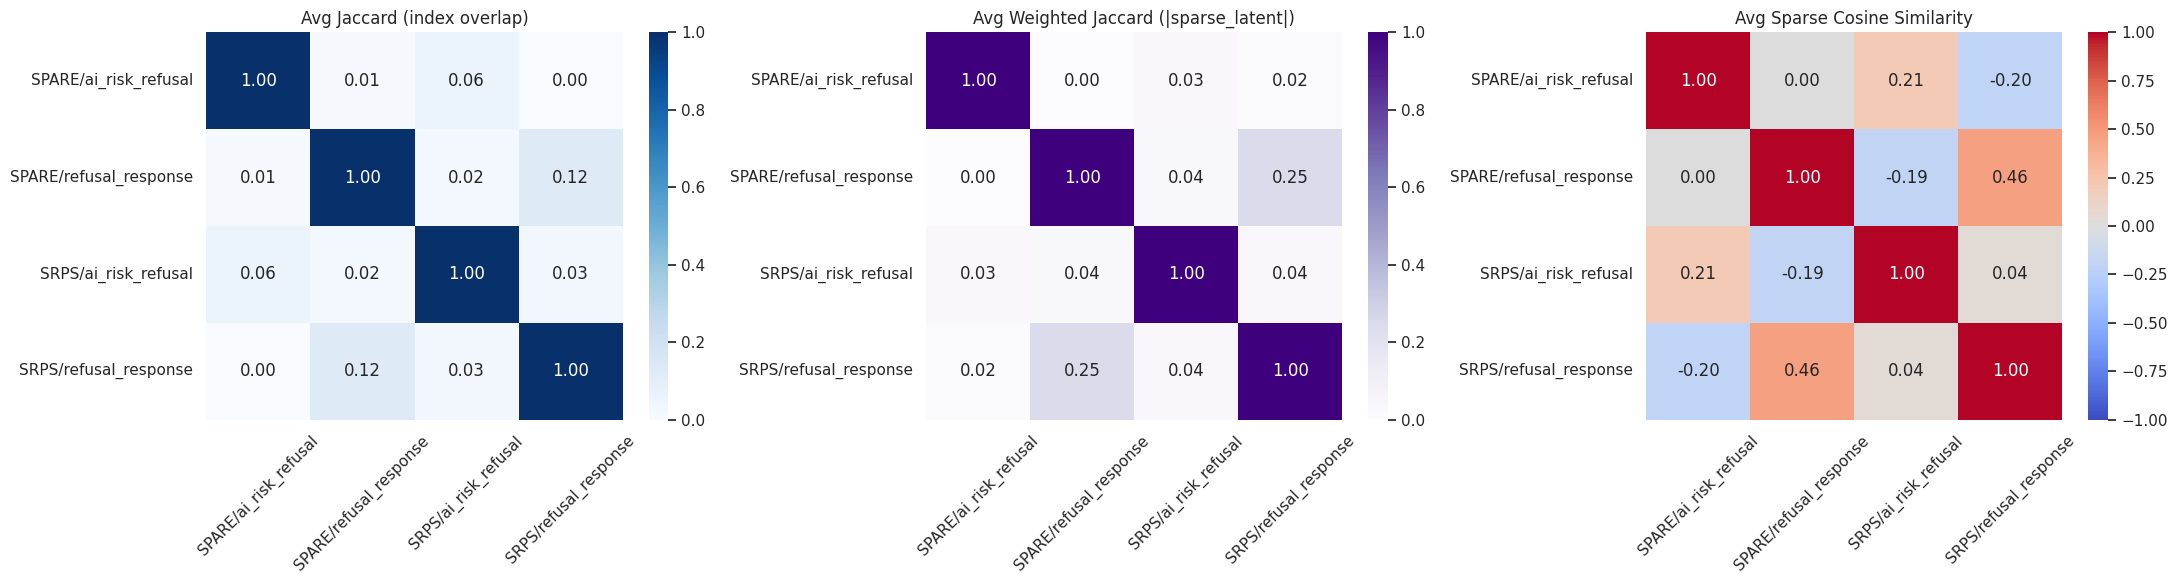

In [37]:
def make_symmetric_metric_matrix(summary_df, labels, metric_col, diag_value=np.nan):
    mat = pd.DataFrame(np.nan, index=labels, columns=labels)
    for _, r in summary_df.iterrows():
        l = r['left']
        rr = r['right']
        v = r.get(metric_col, np.nan)
        mat.loc[l, rr] = v
        mat.loc[rr, l] = v
    for lbl in labels:
        mat.loc[lbl, lbl] = diag_value
    return mat

plot_labels = sorted(metadata_by_label.keys())

jaccard_mat = make_symmetric_metric_matrix(pair_summary_df, plot_labels, 'avg_jaccard', diag_value=1.0)
wj_mat = make_symmetric_metric_matrix(pair_summary_df, plot_labels, 'avg_weighted_jaccard_abs_sparse', diag_value=1.0)
cos_mat = make_symmetric_metric_matrix(pair_summary_df, plot_labels, 'avg_sparse_cosine', diag_value=1.0)

fig, axes = plt.subplots(1, 3, figsize=(22, 6))

sns.heatmap(jaccard_mat, annot=True, fmt='.2f', cmap='Blues', vmin=0, vmax=1, ax=axes[0])
axes[0].set_title('Avg Jaccard (index overlap)')

sns.heatmap(wj_mat, annot=True, fmt='.2f', cmap='Purples', vmin=0, vmax=1, ax=axes[1])
axes[1].set_title('Avg Weighted Jaccard (|sparse_latent|)')

sns.heatmap(cos_mat, annot=True, fmt='.2f', cmap='coolwarm', vmin=-1, vmax=1, ax=axes[2])
axes[2].set_title('Avg Sparse Cosine Similarity')

for ax in axes:
    ax.tick_params(axis='x', rotation=45)
    ax.tick_params(axis='y', rotation=0)

plt.tight_layout()
plt.show()

In [38]:
# Optional focused view for one specific comparison
FOCUS_LEFT = 'SAS/ai_risk_refusal'
FOCUS_RIGHT = 'SPARE/refusal_response'
FOCUS_LAYER = None  # None => first available common layer

focus_rows = pair_layer_df[(pair_layer_df['left'] == FOCUS_LEFT) & (pair_layer_df['right'] == FOCUS_RIGHT)].copy()
if focus_rows.empty:
    focus_rows = pair_layer_df[(pair_layer_df['left'] == FOCUS_RIGHT) & (pair_layer_df['right'] == FOCUS_LEFT)].copy()

if focus_rows.empty:
    raise ValueError(f'No pair rows found for {FOCUS_LEFT} vs {FOCUS_RIGHT}.')

if FOCUS_LAYER is None:
    layer_use = int(sorted(focus_rows['layer'].unique())[0])
else:
    layer_use = int(FOCUS_LAYER)

fr = focus_rows[focus_rows['layer'] == layer_use]
if fr.empty:
    raise ValueError(f'Layer {layer_use} not available for selected focus pair.')

fr = fr.iloc[0]

# Build rank-overlap curve for the focus pair and layer
idx_l = get_top_idx(metadata_by_label[FOCUS_LEFT], layer_use, include_neg=INCLUDE_TOP_IDX_NEG)
idx_r = get_top_idx(metadata_by_label[FOCUS_RIGHT], layer_use, include_neg=INCLUDE_TOP_IDX_NEG)

k_vals = sorted(set(TOPK_GRID))
rk_rows = []
for k in k_vals:
    rk_rows.append({
        'k': int(k),
        'rank_overlap': rank_overlap_at_k(idx_l, idx_r, k),
    })
rk_df = pd.DataFrame(rk_rows)

counts_df = pd.DataFrame([
    {'metric': 'n_left', 'value': fr['n_left']},
    {'metric': 'n_right', 'value': fr['n_right']},
    {'metric': 'n_intersection', 'value': fr['n_intersection']},
    {'metric': 'n_union', 'value': fr['n_union']},
])

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

sns.barplot(data=counts_df, x='metric', y='value', ax=axes[0])
axes[0].set_title(f'Feature Counts: {FOCUS_LEFT} vs {FOCUS_RIGHT} (layer={layer_use})')
axes[0].tick_params(axis='x', rotation=25)

sns.lineplot(data=rk_df, x='k', y='rank_overlap', marker='o', ax=axes[1])
axes[1].set_ylim(0, 1)
axes[1].set_title(f'Rank Overlap@k (layer={layer_use})')
axes[1].set_xlabel('k')
axes[1].set_ylabel('overlap proportion')

plt.tight_layout()
plt.show()

print('Focused scalar metrics:')
display(pd.DataFrame([fr.to_dict()]))

ValueError: No pair rows found for SAS/ai_risk_refusal vs SPARE/refusal_response.